# Airline Passenger Satisfaction — Tabular ML (EDA → Model Selection → Tuning → Final)

Notebook này làm **đầy đủ quy trình chọn mô hình hợp lý**:
1) EDA  
2) Baseline (Dummy)  
3) Model zoo (CV) — chạy nhiều model để so sánh công bằng  
4) Chọn model theo tiêu chí (ưu tiên F1, tie-break ROC-AUC, xét std) + **log chọn/loại**  
5) Tuning model được chọn  
6) Train full → Evaluate test  
7) Lưu artifacts + features theo yêu cầu nộp bài

In [36]:
# from google.colab import drive
# drive.mount('/content/drive')

# 0. Setup Environment and Download Data

## 0.1. Setup Environment

In [37]:
# =========================
# 0.1) Config (hỗ trợ --out_dir)
# =========================
import os, json, shlex, argparse, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Nếu chạy trong notebook: chỉnh dòng này để truyền flag kiểu CLI
# Ví dụ:
#   CLI_ARGS = "--out_dir /content/drive/MyDrive/ML_Project/runs/exp1/ --fast"
# CLI_ARGS = "--out_dir /content/drive/MyDrive/ML_Project/runs/exp1/ --fast"
CLI_ARGS = "--out_dir outputs"

def parse_args(cli_args: str = ""):
    parser = argparse.ArgumentParser(add_help=False)
    parser.add_argument("--out_dir", type=str, default=".", help="Thư mục lưu outputs (artifacts/features/eda_outputs).")
    parser.add_argument("--data_dir", type=str, default="data", help="Thư mục chứa train.csv/test.csv (mặc định ./data).")
    parser.add_argument("--fast", action="store_true", help="Chạy nhẹ hơn (ít fold, ít model, bỏ tuning).")
    parser.add_argument("--seed", type=int, default=42, help="Random seed.")
    if cli_args.strip() == "":
        # Filter out Jupyter kernel arguments
        filtered_argv = [arg for arg in sys.argv if 'kernel' not in arg.lower() and not arg.endswith('.json')]
        args, _ = parser.parse_known_args(filtered_argv[1:])  # Skip first arg (script name)
    else:
        args = parser.parse_args(shlex.split(cli_args))
    return args

args = parse_args(CLI_ARGS)

RANDOM_STATE = int(args.seed)

# --- START: Set Global Seed ---
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Global seed set to: {seed}")

set_seed(RANDOM_STATE)
# --- END: Set Global Seed ---

TARGET_COL = "satisfaction"
DROP_COLS_CANDIDATES = ["Unnamed: 0", "id"]

FAST_MODE = bool(args.fast)

# Resolve dirs
OUT_DIR = Path(args.out_dir).expanduser().resolve()
DATA_DIR = Path(args.data_dir).expanduser()
if not DATA_DIR.is_absolute():
    DATA_DIR = (Path.cwd() / DATA_DIR).resolve()

# Tự tạo thư mục data nếu chưa có
DATA_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_DIR = OUT_DIR / "artifacts"
FEATURES_DIR  = OUT_DIR / "features"
EDA_DIR       = OUT_DIR / "eda_outputs"

for d in [OUT_DIR, ARTIFACTS_DIR, FEATURES_DIR, EDA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("FAST_MODE:", FAST_MODE)
print("OUT_DIR:", OUT_DIR)
print("DATA_DIR:", DATA_DIR)


Global seed set to: 42
FAST_MODE: False
OUT_DIR: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs
DATA_DIR: /mnt/d/wsl-data/Document/ML_252/notebooks/data


## 0.2 Download Data

In [38]:
!pip install kagglehub

In [39]:
# =========================
# 0.2) Download data từ Kaggle bằng kagglehub (tuỳ chọn)
# =========================
# Nếu bạn đã có sẵn train.csv/test.csv trong DATA_DIR thì có thể bỏ qua cell này.

try:
    import kagglehub
    import shutil

    # Download dataset
    source_path = Path(kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction"))

    DATA_DIR.mkdir(parents=True, exist_ok=True)

    for item in source_path.iterdir():
        destination = DATA_DIR / item.name
        if destination.exists():
            if destination.is_dir():
                shutil.rmtree(destination)
            else:
                destination.unlink()

        # Use copy2 instead of move to avoid Read-only file system errors on source
        if item.is_dir():
            shutil.copytree(str(item), str(destination))
        else:
            shutil.copy2(str(item), str(destination))

    print("Downloaded from:", source_path)
    print("Copied dataset files to:", DATA_DIR.resolve())
except Exception as e:
    print("Không chạy được kagglehub (có thể bạn chưa cài hoặc đang offline).")
    print("Nếu cần, cài: pip install kagglehub")
    print("Lỗi:", e)

Downloaded from: /home/godminhkhoa/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1
Copied dataset files to: /mnt/d/wsl-data/Document/ML_252/notebooks/data


## 0.3 Load data

In [40]:
# =========================
# 0.3) Load data
# =========================
assert DATA_DIR.exists(), f"Không thấy DATA_DIR: {DATA_DIR}"

csvs = list(DATA_DIR.glob("*.csv"))
print("CSV in DATA_DIR:", [p.name for p in csvs])

train_path = DATA_DIR / "train.csv"
test_path  = DATA_DIR / "test.csv"

if not train_path.exists() or not test_path.exists():
    # fallback theo tên chứa train/test
    for p in csvs:
        name = p.name.lower()
        if "train" in name:
            train_path = p
        if "test" in name:
            test_path = p

assert train_path.exists(), f"Không tìm thấy train.csv trong {DATA_DIR}"
assert test_path.exists(), f"Không tìm thấy test.csv trong {DATA_DIR}"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train:", train_df.shape, "|", train_path)
print("Test :", test_df.shape, "|", test_path)
train_df.head()

CSV in DATA_DIR: ['test.csv', 'train.csv']
Train: (103904, 25) | /mnt/d/wsl-data/Document/ML_252/notebooks/data/train.csv
Test : (25976, 25) | /mnt/d/wsl-data/Document/ML_252/notebooks/data/test.csv


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# 1. EDA

## 1.1 Info + describe

In [41]:
# 1.1) Info + describe
display(train_df.info())
display(train_df.describe(include="all").T.head(40))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,NaN,NaN,NaN,51951.5,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,NaN,NaN,NaN,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Gender,103904,2,Female,52727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103904,2,Loyal Customer,84923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103904.0,NaN,NaN,NaN,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Type of Travel,103904,2,Business travel,71655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103904,3,Business,49665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,103904.0,NaN,NaN,NaN,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,NaN,NaN,NaN,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,NaN,NaN,NaN,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0


## 1.2 Target distribution

Target unique values: ['neutral or dissatisfied' 'satisfied']


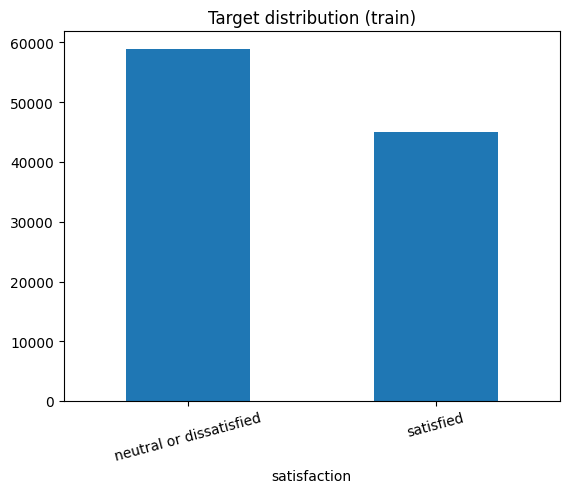

satisfaction
neutral or dissatisfied    0.566667
satisfied                  0.433333
Name: proportion, dtype: float64

In [42]:
# 1.2) Target distribution
print("Target unique values:", train_df[TARGET_COL].unique())
target_map = {"neutral or dissatisfied": 0, "satisfied": 1}

fig = plt.figure()
train_df[TARGET_COL].value_counts().plot(kind="bar")
plt.title("Target distribution (train)")
plt.xticks(rotation=15)
plt.show()

display(train_df[TARGET_COL].value_counts(normalize=True).rename("proportion"))

## 1.3 Missing values (train/test)

In [43]:
# 1.3) Missing values (train/test)
missing_train = train_df.isna().sum().sort_values(ascending=False)
missing_test  = test_df.isna().sum().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_train": missing_train,
    "missing_test": missing_test
})
missing_summary["missing_rate_train"] = missing_summary["missing_train"] / len(train_df)
missing_summary["missing_rate_test"]  = missing_summary["missing_test"] / len(test_df)

display(missing_summary[(missing_summary["missing_train"] + missing_summary["missing_test"]) > 0])

,missing_train,missing_test,missing_rate_train,missing_rate_test
Arrival Delay in Minutes,310,83,0.002984,0.003195


## 1.4 Categorical vs Numeric + split X/y

In [44]:
# 1.4) Categorical vs Numeric + split X/y
drop_cols = [c for c in DROP_COLS_CANDIDATES if c in train_df.columns]
print("Drop cols:", drop_cols)

X_full = train_df.drop(columns=[TARGET_COL] + drop_cols)
y_full = train_df[TARGET_COL].map(target_map)

X_test = test_df.drop(columns=[TARGET_COL] + drop_cols)
y_test = test_df[TARGET_COL].map(target_map)

cat_cols = X_full.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_full.columns if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols[:10], "... total:", len(num_cols))

Drop cols: ['Unnamed: 0', 'id']
Categorical cols: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Numeric cols: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment'] ... total: 18


## 1.5 Insight nhanh: tỉ lệ satisfied theo nhóm categorical

In [45]:
# 1.5) Insight nhanh: tỉ lệ satisfied theo nhóm categorical
for c in cat_cols:
    print("\n===", c, "===")
    display(train_df[c].value_counts())
    display(pd.crosstab(train_df[c], train_df[TARGET_COL], normalize="index").round(3))


=== Gender ===


Gender
Female    52727
Male      51177
Name: count, dtype: int64

satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,0.573,0.427
Male,0.561,0.439



=== Customer Type ===


Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64

...

Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,0.417,0.583
Personal Travel,0.898,0.102



=== Class ===


Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,0.306,0.694
Eco,0.814,0.186
Eco Plus,0.754,0.246


## 1.6 Histogram vài cột số

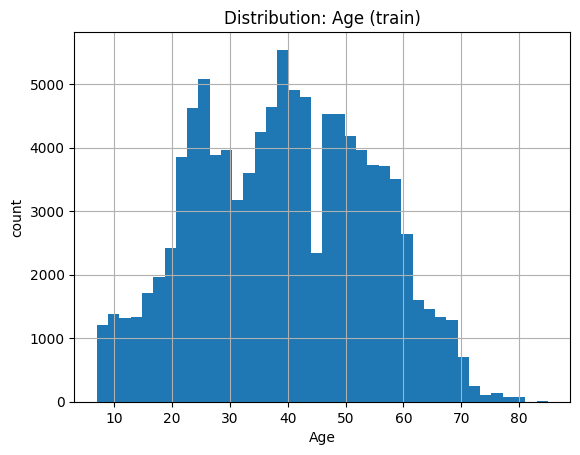

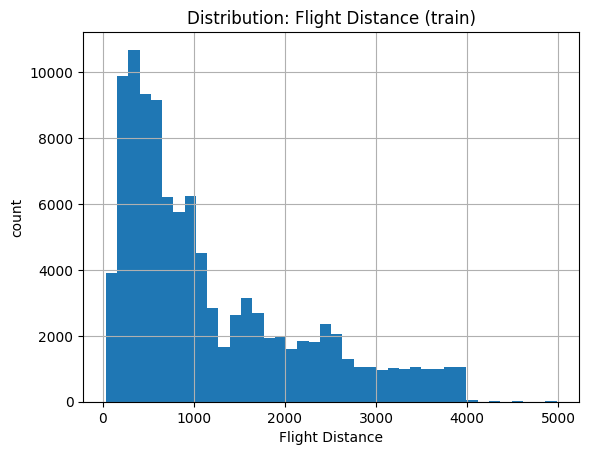

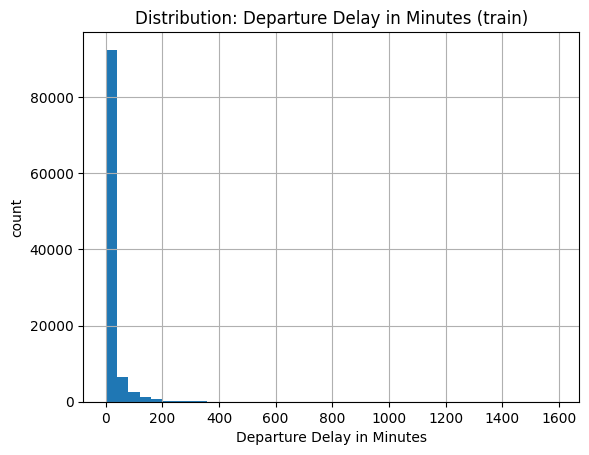

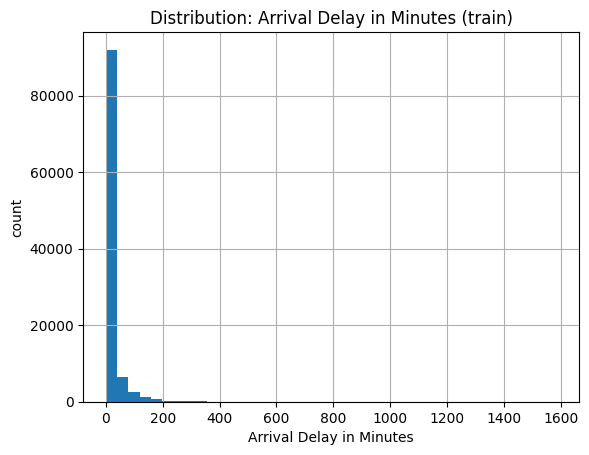

In [46]:
# 1.6) Histogram vài cột số
num_to_plot = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
num_to_plot = [c for c in num_to_plot if c in train_df.columns]

for c in num_to_plot:
    fig = plt.figure()
    train_df[c].hist(bins=40)
    plt.title(f"Distribution: {c} (train)")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()

## 1.7 Correlation numeric vs target

,corr_with_target
target_bin,1.000000
Online boarding,0.503557
Inflight entertainment,0.398059
Seat comfort,0.349459
On-board service,0.322383
Leg room service,0.313131
Cleanliness,0.305198
Flight Distance,0.298780
Inflight wifi service,0.284245
Baggage handling,0.247749


,corr_with_target
Cleanliness,0.305198
Flight Distance,0.298780
Inflight wifi service,0.284245
Baggage handling,0.247749
Inflight service,0.244741
Checkin service,0.236174
Food and drink,0.209936
Ease of Online booking,0.171705
Age,0.137167
id,0.013734


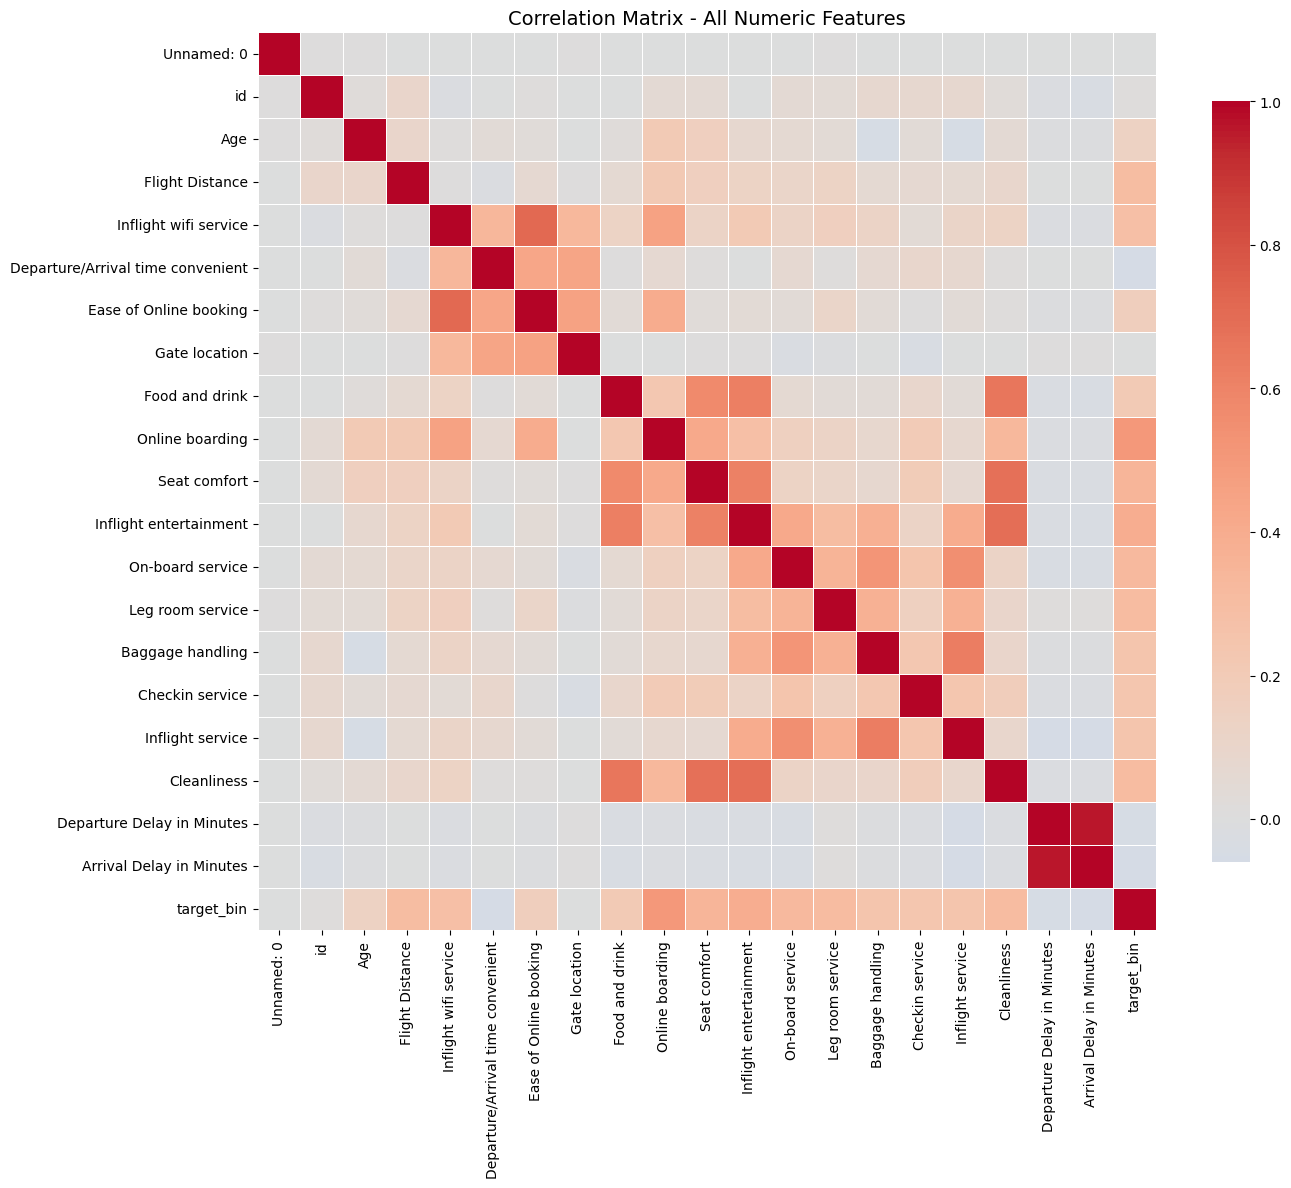

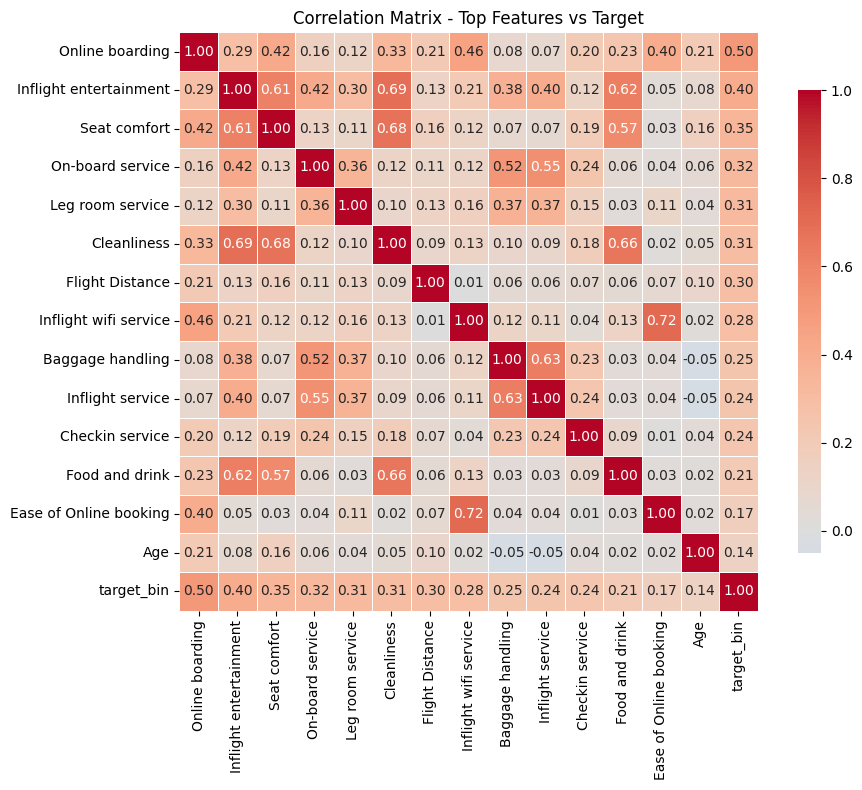

In [47]:
# 1.7) Correlation numeric vs target
import seaborn as sns

tmp = train_df.copy()
tmp["target_bin"] = tmp[TARGET_COL].map(target_map)

# Correlation với target
corr = tmp.drop(columns=[TARGET_COL]).corr(numeric_only=True)["target_bin"].sort_values(ascending=False)
display(corr.head(15).to_frame("corr_with_target"))
display(corr.tail(15).to_frame("corr_with_target"))

# Correlation matrix heatmap
corr_matrix = tmp.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number]).corr()

# Plot full correlation matrix
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title("Correlation Matrix - All Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

# Plot top features correlated với target
top_features = corr.head(15).index.tolist()
if "target_bin" in top_features:
    top_features.remove("target_bin")
else:
    top_features = top_features[:14]

top_corr_matrix = tmp[top_features + ["target_bin"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title("Correlation Matrix - Top Features vs Target", fontsize=12)
plt.tight_layout()
plt.show()


## 1.8 Boxplot (numeric) để kiểm tra outliers


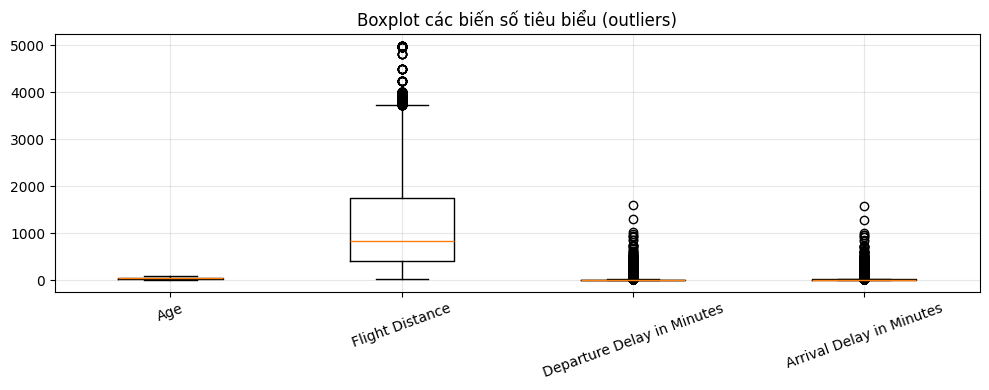

In [48]:

# 1.8) Boxplot một vài cột số (outliers)
import matplotlib.pyplot as plt

num_cols_focus = [c for c in ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"] if c in X_full.columns]
if len(num_cols_focus) == 0:
    print("Không tìm thấy các cột số tiêu biểu để vẽ boxplot.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot([X_full[c].dropna().values for c in num_cols_focus], labels=num_cols_focus, showfliers=True)
    ax.set_title("Boxplot các biến số tiêu biểu (outliers)")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 1.9 Mutual Information (MI) để xem đặc trưng nào liên quan đến nhãn


,MI_score
num__Online boarding,0.214510
num__Inflight wifi service,0.164366
cat__Class_Business,0.132200
cat__Type of Travel_Business travel,0.111707
cat__Type of Travel_Personal Travel,0.111707
cat__Class_Eco,0.105890
num__Inflight entertainment,0.094858
num__Seat comfort,0.082094
num__Leg room service,0.061587
num__Flight Distance,0.058499


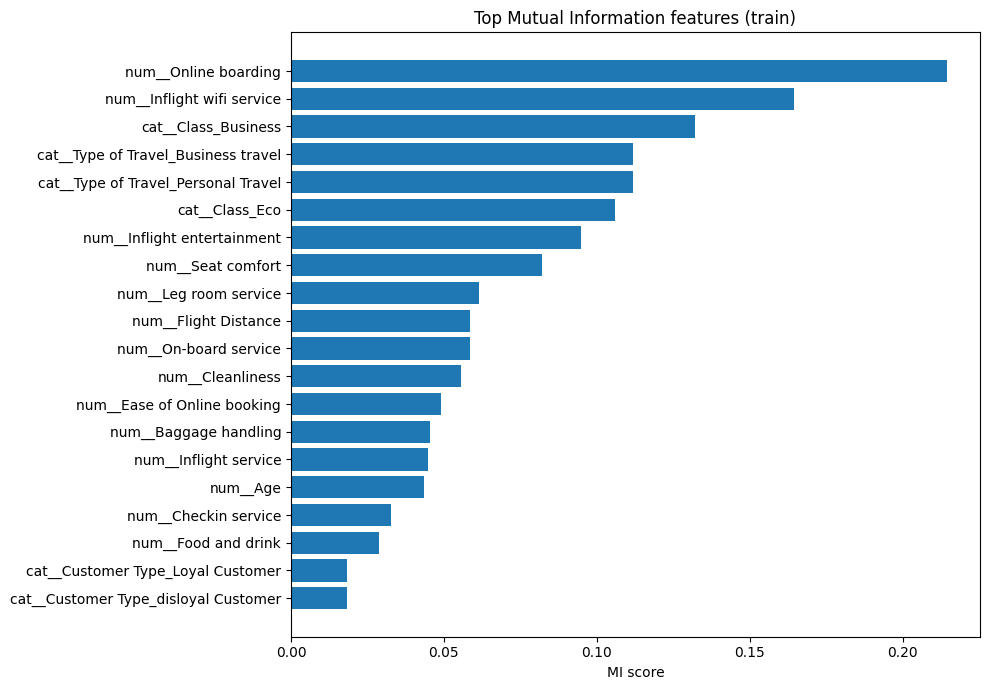

In [49]:

# 1.9) Mutual Information (MI) trên dữ liệu đã one-hot (EDA)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

# Subsample để chạy nhanh hơn (MI khá nặng với 100k+ rows)
mi_sample_n = 30000 if FAST_MODE else 60000
if len(X_full) > mi_sample_n:
    X_mi_df = X_full.sample(mi_sample_n, random_state=RANDOM_STATE)
    y_mi = y_full.loc[X_mi_df.index]
else:
    X_mi_df = X_full
    y_mi = y_full

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

pre_for_mi = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
], remainder="drop", sparse_threshold=0.3)

X_mi = pre_for_mi.fit_transform(X_mi_df, y_mi)

feat_names = pre_for_mi.get_feature_names_out()

# heuristic: one-hot là discrete
is_discrete = np.array([name.startswith("cat__") for name in feat_names], dtype=bool)

mi = mutual_info_classif(X_mi, y_mi, discrete_features=is_discrete, random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=feat_names).sort_values(ascending=False)

display(mi_s.head(20).to_frame("MI_score"))

# plot top 20
topN = 20
mi_top = mi_s.head(topN).iloc[::-1]
plt.figure(figsize=(10, max(6, 0.35*topN)))
plt.barh(mi_top.index, mi_top.values)
plt.title("Top Mutual Information features (train)")
plt.xlabel("MI score")
plt.tight_layout()
plt.show()


# 2. Traditional ML

## 2.1 Preprocess + Pipeline

In [50]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD

class SafeTruncatedSVD(BaseEstimator, TransformerMixin):
    """TruncatedSVD an toàn: tự động giới hạn n_components <= n_features."""
    def __init__(self, n_components=32, random_state=42):
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        n_features = X.shape[1]
        n_comp = int(min(self.n_components, n_features))
        if n_comp < 1:
            raise ValueError(f"Không thể SVD vì n_features={n_features}")
        self.n_components_ = n_comp
        self.svd_ = TruncatedSVD(n_components=self.n_components_, random_state=self.random_state)
        self.svd_.fit(X, y)
        return self

    def transform(self, X):
        return self.svd_.transform(X)

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

def build_preprocessor(scaler: str | None = "standard") -> ColumnTransformer:
    if scaler in (None, "none"):
        scaler_obj = "passthrough"
    elif scaler == "standard":
        scaler_obj = StandardScaler()
    elif scaler == "minmax":
        scaler_obj = MinMaxScaler()
    else:
        raise ValueError("scaler must be one of: standard, minmax, none")

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler_obj),
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ], remainder="drop", sparse_threshold=0.3)

    return pre

def make_pipeline(model, scaler="standard", use_svd=False, n_components=32):
    steps = [("preprocess", build_preprocessor(scaler=scaler))]
    if use_svd:
        steps.append(("svd", SafeTruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)

## 2.2 Baseline + Model Zoo (CV) + Log chọn/loại

**Cross-validation (StratifiedKFold).**  
Mình dùng *StratifiedKFold* để đảm bảo **tỷ lệ nhãn ở mỗi fold gần giống nhau**, đặc biệt quan trọng khi dữ liệu có thể **mất cân bằng lớp**. Cách này giúp điểm số ổn định và công bằng hơn so với KFold thường.

**Số fold (3 vs 5).**
- Khi chạy bình thường (không FAST_MODE): dùng **5-fold** để ước lượng tổng quát hóa **ổn định hơn** (giảm “hên xui” theo cách chia dữ liệu).
- Khi cần chạy nhanh (FAST_MODE): dùng **3-fold** để giảm thời gian (ít lần huấn luyện hơn), phù hợp giai đoạn thử nghiệm/iterate.

**Thước đo (metrics).**
- **Accuracy**: dễ hiểu nhưng có thể “đẹp giả” nếu dữ liệu lệch lớp.
- **F1-score**: cân bằng Precision/Recall cho lớp dương (mặc định `pos_label=1`), hữu ích khi quan tâm phát hiện đúng lớp quan trọng.
- **ROC-AUC**: đo chất lượng *xếp hạng* (ranking) dựa trên xác suất/điểm dự đoán, ít phụ thuộc ngưỡng.

### 2.2.1 Baseline

In [51]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
import numpy as np

def cv_summary(pipe, X, y, cv, scoring):
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    out = {}
    for k in scoring.keys():
        out[f"{k}_mean"] = float(np.mean(res[f"test_{k}"]))
        out[f"{k}_std"]  = float(np.std(res[f"test_{k}"]))
    return out

# CV folds
n_splits = 3 if FAST_MODE else 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

scoring = {"acc": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

# 2.2.1) Baseline
baseline_pipe = make_pipeline(DummyClassifier(strategy="most_frequent"), scaler="none", use_svd=False)
print(f"Running baseline CV ({n_splits} folds) on FULL train...")
baseline_stats = cv_summary(baseline_pipe, X_full, y_full, cv=cv, scoring=scoring)
baseline_stats

Running baseline CV (5 folds) on FULL train...


{'acc_mean': 0.5666673081240133,
 'acc_std': 8.341261236699538e-06,
 'f1_mean': 0.0,
 'f1_std': 0.0,
 'roc_auc_mean': 0.5,
 'roc_auc_std': 0.0}

**Vì sao cần baseline?**  
Baseline là “mốc sàn” để biết mô hình học máy **có thật sự học được gì** hay chỉ ăn may. Ở đây dùng:
- `DummyClassifier(strategy="most_frequent")`: luôn dự đoán **lớp xuất hiện nhiều nhất**.
- Đây là baseline mạnh nhất trong nhóm “ngây thơ” (naive) vì nó tối đa hóa accuracy trong các cách dự đoán hằng số.

**Kết quả baseline (CV trên FULL train):**
- `acc_mean ≈ 0.5667`: mô hình đoán **toàn lớp đa số**, nên accuracy xấp xỉ **tỷ lệ lớp đa số** trong dữ liệu (~56.67%).
- `f1_mean = 0.0`: do mô hình **không bao giờ dự đoán lớp 1** (mặc định F1 tính cho lớp 1), nên Precision/Recall cho lớp 1 đều bằng 0 ⇒ F1 = 0.
- `roc_auc_mean = 0.5`: tương đương **đoán ngẫu nhiên** về mặt ranking (không có khả năng phân biệt hai lớp).

**Ý nghĩa:**  
Nếu các mô hình “xịn” không vượt baseline một cách rõ rệt (đặc biệt ở F1 và ROC-AUC) thì pipeline chưa học được tín hiệu thực sự.

### 2.2.2 Model Zoo (CV)

Mình chọn một tập mô hình đa dạng để bao phủ nhiều “giả định học” khác nhau:

- **Logistic Regression (LogReg)**: mô hình tuyến tính, baseline mạnh cho dữ liệu đặc trưng nhiều chiều; nhanh, dễ giải thích.
- **LinearSVC (calibrated)**: biên phân tách tuyến tính tốt; bản *calibrated* giúp có xác suất/điểm phù hợp để tính ROC-AUC và so sánh công bằng.
- **KNN**: mô hình dựa trên láng giềng, nhạy với khoảng cách; thường hiệu quả khi biểu diễn đặc trưng “tốt” và số chiều không quá cao.
- **RandomForest / ExtraTrees**: ensemble cây quyết định, bắt quan hệ phi tuyến tốt, khá robust; ExtraTrees ngẫu nhiên hơn nên đôi khi tổng quát hóa tốt.
- **HistGradientBoosting**: boosting hiệu quả cho dữ liệu tabular, thường đạt chất lượng rất cao; học phi tuyến mạnh và tối ưu tốt.

Mục tiêu là không “đánh bạc” với 1 họ mô hình, mà **so sánh công bằng nhiều họ** rồi chọn theo CV.

**Standardization (chuẩn hóa).**  
Các mô hình dựa trên khoảng cách/biên như **LogReg, SVM, KNN** nhạy với thang đo đặc trưng. Chuẩn hóa giúp:
- hội tụ ổn định hơn,
- tránh đặc trưng có biên độ lớn “lấn át” đặc trưng khác.

**SVD (giảm chiều, ví dụ SVD(32)).**  
SVD thường hữu ích khi:
- số chiều lớn (đặc biệt đặc trưng dạng sparse/one-hot/TF-IDF),
- có nhiễu/đồng tuyến tính,
- muốn tăng tốc và giảm “lời nguyền số chiều”.

Đặc biệt với **KNN**, giảm chiều giúp khoảng cách có ý nghĩa hơn và giảm chi phí tính khoảng cách.  
Với **mô hình cây (RF/ExtraTrees/HGB)**, giảm chiều thường **không cần thiết** vì cây tự chọn ngưỡng và tương tác đặc trưng theo cách khác (không dựa trên chuẩn hóa/khoảng cách).

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# 2.2.2) Model zoo (FULL CV)
models_fullcv = {}

models_fullcv["LogReg (std)"] = make_pipeline(LogisticRegression(max_iter=3000), scaler="standard")
models_fullcv["LinearSVC calibrated (std)"] = make_pipeline(
    CalibratedClassifierCV(LinearSVC(), method="sigmoid", cv=3),
    scaler="standard",
)
models_fullcv["RandomForest"] = make_pipeline(
    RandomForestClassifier(n_estimators=300 if not FAST_MODE else 200, random_state=RANDOM_STATE, n_jobs=-1),
    scaler="none",
)
models_fullcv["ExtraTrees"] = make_pipeline(
    ExtraTreesClassifier(n_estimators=600 if not FAST_MODE else 300, random_state=RANDOM_STATE, n_jobs=-1),
    scaler="none",
)
models_fullcv["HistGradientBoosting"] = make_pipeline(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    scaler="none",
)
models_fullcv["LogReg + SVD(32)"] = make_pipeline(
    LogisticRegression(max_iter=3000),
    scaler="standard",
    use_svd=True,
    n_components=32
)

models_fullcv["KNN(k=15)+SVD(32)"] = make_pipeline(
    KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1),
    scaler="standard",
    use_svd=True,
    n_components=32
)

# FAST_MODE: giảm bớt model nếu muốn
if FAST_MODE:
    keep = ["LogReg (std)", "RandomForest", "HistGradientBoosting", "KNN(k=15)+SVD(32)"]
    models_fullcv = {k: models_fullcv[k] for k in keep}

print("Evaluating", len(models_fullcv), "models with", n_splits, "fold CV on FULL train...")

rows = []
for name, pipe in models_fullcv.items():
    stats = cv_summary(pipe, X_full, y_full, cv=cv, scoring=scoring)
    rows.append({
        "model": name,
        "eval_data": "full_train",
        "n_samples": int(len(X_full)),
        "cv_folds": int(n_splits),
        **stats
    })

zoo_df = pd.DataFrame(rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)
display(zoo_df)

Evaluating 7 models with 5 fold CV on FULL train...


,model,eval_data,n_samples,cv_folds,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,HistGradientBoosting,full_train,103904,5,0.963399,0.000889,0.957006,0.001091,0.994861,0.000366
1,RandomForest,full_train,103904,5,0.962966,0.001140,0.956551,0.001378,0.994232,0.000404
2,ExtraTrees,full_train,103904,5,0.960820,0.001578,0.954086,0.001913,0.993463,0.000457
3,KNN(k=15)+SVD(32),full_train,103904,5,0.928001,0.001619,0.913720,0.002071,0.979416,0.001243
4,LogReg (std),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
5,LogReg + SVD(32),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
6,LinearSVC calibrated (std),full_train,103904,5,0.874115,0.002563,0.851853,0.003051,0.926117,0.001955


Bảng này tổng hợp kết quả **cross-validation 5-fold** trên `full_train` với `n_samples = 103904`.  
Ý nghĩa các cột chính:
- `acc_mean`, `f1_mean`, `roc_auc_mean`: điểm trung bình qua 5 fold.
- `*_std`: độ lệch chuẩn theo fold (càng nhỏ ⇒ càng ổn định).

**Nhận xét theo kết quả hiển thị:**
- **HistGradientBoosting** đạt cao nhất: `acc_mean ≈ 0.9634`, `f1_mean ≈ 0.9570`, `roc_auc_mean ≈ 0.9949` và std rất nhỏ ⇒ vừa **mạnh** vừa **ổn định**.
- **RandomForest** và **ExtraTrees** bám rất sát (F1 chỉ thấp hơn nhẹ), cho thấy ensemble cây hoạt động rất tốt trên dữ liệu này.
- **KNN(k=15)+SVD(32)** thấp hơn rõ (F1 ~0.914), dù đã giảm chiều; hợp lý vì KNN thường khó cạnh tranh với boosting/forest khi dữ liệu lớn và biên quyết định phức tạp.
- **LogReg / LinearSVC** thấp hơn nhiều (F1 ~0.85), gợi ý quan hệ giữa đặc trưng và nhãn **không thuần tuyến tính** hoặc cần mô hình phi tuyến mạnh hơn.
- `LogReg + SVD(32)` gần như không đổi so với `LogReg(std)` ⇒ giảm chiều ở cấu hình này **không mang lại lợi ích** (có thể vì số chiều/biểu diễn hiện tại đã phù hợp hoặc SVD làm mất tín hiệu tuyến tính quan trọng).

Kết luận từ bảng: nhóm mô hình cây/boosting là ứng viên tốt nhất; HGB đang dẫn đầu.

### 2.2.3 Model selection log

In [53]:
# 2.2.3) Model selection log (rõ đã thử bao nhiêu model + lý do chọn/loại)
baseline_f1  = baseline_stats["f1_mean"]
baseline_auc = baseline_stats["roc_auc_mean"]

log_df = zoo_df.copy()
log_df["f1_gain_vs_baseline"]  = log_df["f1_mean"] - baseline_f1
log_df["auc_gain_vs_baseline"] = log_df["roc_auc_mean"] - baseline_auc

# Chỉ chọn best từ nhóm full_train (điều kiện đánh giá công bằng)
full = log_df[log_df["eval_data"] == "full_train"].copy()
full = full.sort_values(["f1_mean", "roc_auc_mean"], ascending=False).reset_index(drop=True)
full["rank_fullcv"] = np.arange(1, len(full) + 1)

best_name = full.loc[0, "model"]
best_f1 = float(full.loc[0, "f1_mean"])
best_auc = float(full.loc[0, "roc_auc_mean"])

log_df["decision"] = "rejected"
log_df.loc[log_df["model"] == best_name, "decision"] = "SELECTED (best full CV)"

display(log_df.sort_values(["eval_data", "decision", "f1_mean"], ascending=[True, False, False]).reset_index(drop=True))
print("Selected model:", best_name)
print("Tổng số model đã thử:", len(log_df))
print("Top 3 full CV:")
display(full[["rank_fullcv", "model", "f1_mean", "roc_auc_mean", "f1_std"]].head(3))


,model,eval_data,n_samples,cv_folds,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,f1_gain_vs_baseline,auc_gain_vs_baseline,decision
0,RandomForest,full_train,103904,5,0.962966,0.001140,0.956551,0.001378,0.994232,0.000404,0.956551,0.494232,rejected
1,ExtraTrees,full_train,103904,5,0.960820,0.001578,0.954086,0.001913,0.993463,0.000457,0.954086,0.493463,rejected
2,KNN(k=15)+SVD(32),full_train,103904,5,0.928001,0.001619,0.913720,0.002071,0.979416,0.001243,0.913720,0.479416,rejected
3,LogReg (std),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891,0.853086,0.426676,rejected
4,LogReg + SVD(32),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891,0.853086,0.426676,rejected
5,LinearSVC calibrated (std),full_train,103904,5,0.874115,0.002563,0.851853,0.003051,0.926117,0.001955,0.851853,0.426117,rejected
6,HistGradientBoosting,full_train,103904,5,0.963399,0.000889,0.957006,0.001091,0.994861,0.000366,0.957006,0.494861,SELECTED (best full CV)


Selected model: HistGradientBoosting
Tổng số model đã thử: 7
Top 3 full CV:


,rank_fullcv,model,f1_mean,roc_auc_mean,f1_std
0,1,HistGradientBoosting,0.957006,0.994861,0.001091
1,2,RandomForest,0.956551,0.994232,0.001378
2,3,ExtraTrees,0.954086,0.993463,0.001913


Bảng này là lớp “ra quyết định” dựa trên kết quả CV, gồm thêm hai cột so với baseline:

### (1) `f1_gain_vs_baseline` và `auc_gain_vs_baseline`
- Baseline có `f1 = 0.0` và `roc_auc = 0.5`.
- Vì vậy:
  - `f1_gain_vs_baseline = f1_mean - 0.0 = f1_mean`
  - `auc_gain_vs_baseline = roc_auc_mean - 0.5`
Ví dụ `roc_auc_mean ≈ 0.994861` ⇒ `auc_gain_vs_baseline ≈ 0.494861`.

Ý nghĩa: mô hình tốt phải **vượt baseline rõ rệt** (đặc biệt ở F1 và AUC), tránh trường hợp accuracy cao do lệch lớp.

### (2) `decision` và `reason`
- `SELECTED (best full CV)`: mô hình được chọn làm **best** theo tiêu chí chính.
- `rejected`: không chọn vì thua mô hình tốt nhất.

**Logic chọn (theo thông điệp reason trong bảng):**
- Tiêu chí chính: **chọn mô hình có F1 cao nhất** trên full CV.
- Nếu F1 gần bằng nhau (hoặc cần tie-break): dùng **ROC-AUC** để phân giải (tie-break ROC-AUC).
- Một số dòng có ghi `(p<0.01)`: nghĩa là chênh lệch F1 so với best được xem là **khác biệt có ý nghĩa thống kê** dựa trên điểm theo từng fold (mục đích: tránh kết luận do nhiễu chia fold).

**Diễn giải nhanh theo bảng:**
- **HistGradientBoosting** được chọn vì **F1 cao nhất**; đồng thời ROC-AUC cũng rất cao ⇒ `SELECTED`.
- **RandomForest / ExtraTrees** bị loại vì “F1 thấp hơn nhẹ so với best” (sát nhưng vẫn thua).
- **KNN / LogReg / LinearSVC** bị loại vì “F1 thấp hơn rõ rệt so với best” (thậm chí có dòng nhấn mạnh ý nghĩa thống kê).

- Baseline cho thấy dữ liệu có xu hướng lệch lớp (accuracy ~0.5667 nhưng F1=0), nên **F1 và ROC-AUC** là thước đo quan trọng hơn accuracy.
- Kết quả 5-fold CV cho thấy nhóm mô hình cây/boosting vượt trội rõ rệt, đặc biệt:
  - HistGradientBoosting ≈ tốt nhất và ổn định (std nhỏ).
  - RF/ExtraTrees rất cạnh tranh nhưng vẫn nhỉnh kém.
- SVD giúp KNN “đỡ” hơn trong bối cảnh nhiều chiều, nhưng vẫn không vượt được mô hình phi tuyến mạnh (boosting/forest).
- Bảng decision giúp “chốt” lựa chọn theo nguyên tắc: **F1 tối ưu**, tie-break bằng **ROC-AUC**, và có cân nhắc độ chắc chắn qua các fold.

## 2.3 Tuning model được chọn

In [54]:
from sklearn.model_selection import RandomizedSearchCV

selected_pipe = models_fullcv[best_name]
param_distributions = {}

if "LogReg" in best_name:
    param_distributions = {"model__C": np.logspace(-3, 2, 20), "model__penalty": ["l2"]}
elif "RandomForest" in best_name:
    param_distributions = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    }
elif "ExtraTrees" in best_name:
    param_distributions = {
        "model__n_estimators": [300, 600, 900],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    }
elif "HistGradientBoosting" in best_name:
    param_distributions = {
        "model__learning_rate": [0.02, 0.05, 0.1, 0.2],
        "model__max_depth": [None, 3, 5, 7],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [20, 50, 100],
    }
elif "SVC" in best_name:
    param_distributions = {"model__base_estimator__C": np.logspace(-3, 2, 15)}

do_tuning = not FAST_MODE
print("Tuning enabled:", do_tuning)

if do_tuning and len(param_distributions) > 0:
    cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    n_iter = 25 if not FAST_MODE else 10

    search = RandomizedSearchCV(
        selected_pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="f1",
        cv=cv_tune,
        n_jobs=-1,
        verbose=1,
        random_state=RANDOM_STATE
    )
    search.fit(X_full, y_full)
    print("Best params:", search.best_params_)
    print("Best CV F1:", search.best_score_)
    tuned_pipe = search.best_estimator_
else:
    tuned_pipe = selected_pipe
    print("Skip tuning.")

Tuning enabled: True
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 63, 'model__max_depth': None, 'model__learning_rate': 0.1}
Best CV F1: 0.958611870187856


## 2.4 Final: train full → evaluate test

Test metrics:
  Accuracy : 0.9644287034185401
  Precision: 0.9754968690443779
  Recall   : 0.9426466719284399
  F1       : 0.9587904736419588
  ROC-AUC  : 0.9955515606325606

Classification report:
              precision    recall  f1-score   support

           0     0.9563    0.9815    0.9687     14573
           1     0.9755    0.9426    0.9588     11403

    accuracy                         0.9644     25976
   macro avg     0.9659    0.9621    0.9638     25976
weighted avg     0.9647    0.9644    0.9644     25976



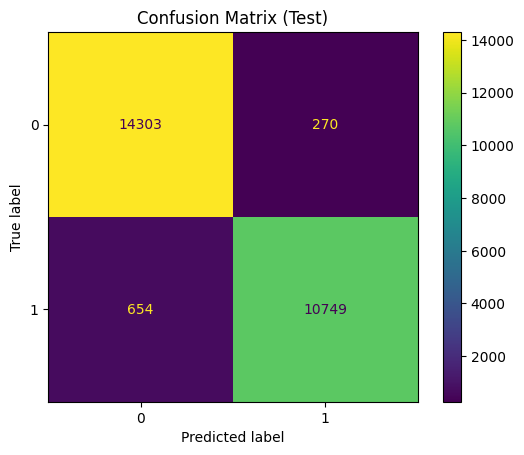

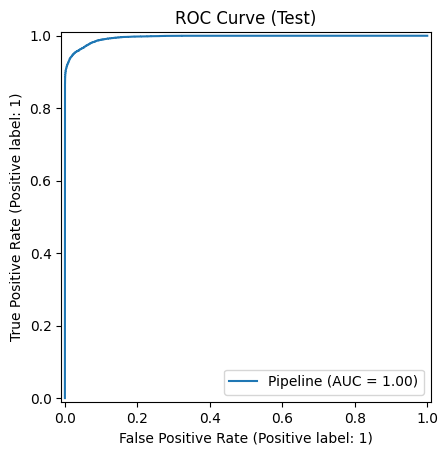

In [55]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

tuned_pipe.fit(X_full, y_full)
test_pred = tuned_pipe.predict(X_test)

print("Test metrics:")
print("  Accuracy :", accuracy_score(y_test, test_pred))
print("  Precision:", precision_score(y_test, test_pred))
print("  Recall   :", recall_score(y_test, test_pred))
print("  F1       :", f1_score(y_test, test_pred))

roc_auc = None
if hasattr(tuned_pipe, "predict_proba"):
    test_proba = tuned_pipe.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, test_proba)
elif hasattr(tuned_pipe, "decision_function"):
    test_score = tuned_pipe.decision_function(X_test)
    roc_auc = roc_auc_score(y_test, test_score)

if roc_auc is not None:
    print("  ROC-AUC  :", roc_auc)

print("\nClassification report:")
print(classification_report(y_test, test_pred, digits=4))

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm).plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

try:
    RocCurveDisplay.from_estimator(tuned_pipe, X_test, y_test)
    plt.title("ROC Curve (Test)")
    plt.show()
except Exception as e:
    print("Không vẽ được ROC curve:", e)

### (1) Các chỉ số tổng quát
- **Accuracy = 0.9644**: Tỷ lệ dự đoán đúng trên toàn bộ tập test.  
  \[
  Acc = \frac{TP + TN}{TP + TN + FP + FN}
  \]
  Với ma trận nhầm lẫn bên dưới: \((10749 + 14303) / 25976 \approx 0.9644\).

- **Precision = 0.9755 (cho lớp dương = 1)**: Trong các mẫu **dự đoán là 1**, có bao nhiêu mẫu **thực sự là 1**.  
  \[
  Precision = \frac{TP}{TP + FP}
  \]
  \[
  = \frac{10749}{10749+270} \approx 0.9755
  \]
  ⇒ Mô hình **ít báo động giả** (FP thấp).

- **Recall = 0.9426 (cho lớp dương = 1)**: Trong các mẫu **thực sự là 1**, mô hình bắt được bao nhiêu.  
  \[
  Recall = \frac{TP}{TP + FN}
  \]
  \[
  = \frac{10749}{10749+654} \approx 0.9426
  \]
  ⇒ Vẫn còn **bỏ sót** một phần mẫu dương (FN).

- **F1 = 0.9588**: Trung bình điều hòa giữa Precision và Recall (tốt khi muốn cân bằng báo đúng và bắt đủ).  
  \[
  F1 = \frac{2PR}{P+R}
  \]
  ⇒ F1 cao cho thấy mô hình vừa **chính xác khi dự đoán 1**, vừa **bắt được phần lớn mẫu 1**.

- **ROC-AUC = 0.9956**: Khả năng phân biệt hai lớp theo *ranking score* (ít phụ thuộc ngưỡng).  
  AUC gần 1.0 ⇒ mô hình **tách lớp rất tốt**. (Trong hình ROC, AUC hiển thị 1.00 thường do làm tròn.)


### (2) Classification Report – hiểu các dòng số

Bảng báo cáo theo từng lớp:

- **Lớp 0**: precision 0.9563, recall 0.9815, f1 0.9687 (support 14573)  
  ⇒ Với lớp 0, mô hình **bắt rất đủ** (recall cao ~0.982), nhầm thành 1 tương đối ít.

- **Lớp 1 (positive)**: precision 0.9755, recall 0.9426, f1 0.9588 (support 11403)  
  ⇒ Với lớp 1, mô hình **dự đoán 1 khá “chuẩn”** (precision rất cao), nhưng **recall thấp hơn lớp 0** ⇒ vẫn có một lượng bỏ sót (FN).

- **macro avg**: trung bình đều 2 lớp (mỗi lớp trọng số như nhau) → phản ánh công bằng giữa lớp 0 và 1.
- **weighted avg**: trung bình có trọng số theo support → phản ánh theo phân bố dữ liệu thực tế (lớp nào nhiều ảnh hưởng hơn).

Do support lớp 0 > lớp 1, **weighted avg** thường “nghiêng” theo lớp 0 hơn một chút.


### (4) ROC Curve (Test) – ý nghĩa hình vẽ

ROC Curve biểu diễn trade-off giữa:
- **TPR (Recall của lớp 1)** trên trục y
- **FPR (tỷ lệ báo nhầm 1 khi thật 0)** trên trục x

Đường ROC càng ôm sát góc trên-trái càng tốt.  
AUC ≈ **0.9956** cho thấy mô hình gần như phân biệt hoàn hảo hai lớp (chỉ cần thay đổi ngưỡng là có thể đạt TPR cao với FPR rất thấp).

Lưu ý: trên plot thường ghi **AUC = 1.00** do làm tròn, nhưng giá trị log thực tế là ~0.9956.

## 2.5 Save outputs (theo OUT_DIR)

In [56]:
import joblib
from scipy import sparse

# 2.5.1) Save model pipeline
model_path = ARTIFACTS_DIR / "best_pipeline.joblib"
joblib.dump(tuned_pipe, model_path)
print("Saved:", model_path)

# 2.5.2) Save EDA / selection tables
missing_summary.to_csv(EDA_DIR / "missing_summary.csv")
zoo_df.to_csv(EDA_DIR / "model_zoo_results.csv", index=False)
log_df.to_csv(EDA_DIR / "model_selection_log.csv", index=False)
print("Saved:", EDA_DIR / "missing_summary.csv")
print("Saved:", EDA_DIR / "model_zoo_results.csv")
print("Saved:", EDA_DIR / "model_selection_log.csv")

# 2.5.3) Save transformed features (sparse → npz, dense → npy)
pre = tuned_pipe.named_steps["preprocess"]
Xtr_feat = pre.transform(X_full)
Xte_feat = pre.transform(X_test)

if sparse.issparse(Xtr_feat):
    sparse.save_npz(FEATURES_DIR / "train_features.npz", Xtr_feat)
    sparse.save_npz(FEATURES_DIR / "test_features.npz", Xte_feat)
    print("Saved:", FEATURES_DIR / "train_features.npz")
    print("Saved:", FEATURES_DIR / "test_features.npz")
else:
    np.save(FEATURES_DIR / "train_features.npy", Xtr_feat)
    np.save(FEATURES_DIR / "test_features.npy", Xte_feat)
    print("Saved:", FEATURES_DIR / "train_features.npy")
    print("Saved:", FEATURES_DIR / "test_features.npy")

# 2.5.4) Feature names (nếu có)
feature_names = None
try:
    feature_names = pre.get_feature_names_out().tolist()
except Exception:
    feature_names = None

with open(FEATURES_DIR / "feature_names.json", "w", encoding="utf-8") as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)

print("Saved:", FEATURES_DIR / "feature_names.json")

Saved: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs/artifacts/best_pipeline.joblib
Saved: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs/eda_outputs/missing_summary.csv
Saved: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs/eda_outputs/model_zoo_results.csv
Saved: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs/eda_outputs/model_selection_log.csv
Saved: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs/features/train_features.npy
Saved: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs/features/test_features.npy
Saved: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs/features/feature_names.json


# 4. Reload model đã train (sau khi reset kernel)

Mục tiêu: sau khi đã **lưu `.joblib`**, bạn có thể **load lại pipeline** và **chạy lại evaluation trên test** mà **không cần train lại**.

> Lưu ý: vì pipeline có custom transformer (ví dụ `SafeTruncatedSVD`, feature-engineering function), ta cần chạy cell “Prerequisites” bên dưới trước khi `joblib.load()`.


## 4.0 Prerequisites để reload model

In [57]:
# 4.0) Prerequisites để unpickle pipeline + load data nhanh (chạy cell này trước)
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
from scipy import sparse

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# --- Custom transformer giống Section 2 (cần để load best_pipeline.joblib) ---
class SafeTruncatedSVD(BaseEstimator, TransformerMixin):
    """TruncatedSVD an toàn: tự động giới hạn n_components <= n_features."""
    def __init__(self, n_components=32, random_state=42):
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        n_features = X.shape[1]
        n_comp = int(min(self.n_components, n_features))
        if n_comp < 1:
            raise ValueError(f"Không thể SVD vì n_features={n_features}")
        self._svd = TruncatedSVD(n_components=n_comp, random_state=self.random_state)
        self._svd.fit(X)
        return self

    def transform(self, X):
        return self._svd.transform(X)

# --- Advanced FE function (cần để load best_advanced_model.joblib) ---
def add_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tạo feature dẫn xuất; giữ trong pipeline để tránh leakage."""
    df = df.copy()

    def _safe_mean(cols, new_name):
        ok = [c for c in cols if c in df.columns]
        if len(ok) > 0:
            df[new_name] = df[ok].mean(axis=1)

    # delay/time
    if "Departure Delay in Minutes" in df.columns and "Arrival Delay in Minutes" in df.columns:
        df["total_delay"] = df["Departure Delay in Minutes"].fillna(0) + df["Arrival Delay in Minutes"].fillna(0)
        df["delay_gap"] = (df["Arrival Delay in Minutes"].fillna(0) - df["Departure Delay in Minutes"].fillna(0)).abs()

    comfort = [
        "Seat comfort", "Leg room service", "Cleanliness",
        "Food and drink", "Inflight service", "Inflight entertainment",
        "On-board service"
    ]
    online = ["Ease of Online booking", "Online boarding", "Inflight wifi service"]
    ground = ["Checkin service", "Gate location", "Baggage handling"]

    _safe_mean(comfort, "comfort_mean")
    _safe_mean(online, "online_mean")
    _safe_mean(ground, "ground_mean")

    if "Age" in df.columns:
        df["age_bin"] = pd.cut(df["Age"], bins=[0, 25, 40, 60, 200], labels=["<=25", "26-40", "41-60", "60+"])
    if "Flight Distance" in df.columns:
        df["dist_bin"] = pd.cut(df["Flight Distance"], bins=[0, 500, 1500, 3000, 100000], labels=["short", "mid", "long", "ultra"])

    return df

def _resolve_data_dir():
    if "DATA_DIR" in globals() and isinstance(DATA_DIR, Path) and DATA_DIR.exists():
        return DATA_DIR

    for cand in [Path("./data"), Path("."), Path("/mnt/data")]:
        if (cand / "train.csv").exists() and (cand / "test.csv").exists():
            return cand
    raise FileNotFoundError("Không tìm thấy train.csv/test.csv. Hãy đặt đúng DATA_DIR hoặc để file trong ./data.")

def ensure_xy_loaded():
    """Tạo X_full, y_full, X_test, y_test nếu chưa có (để chạy eval sau reset)."""
    global train_df, test_df, X_full, y_full, X_test, y_test, TARGET_COL, drop_cols, target_map

    if all(name in globals() for name in ["X_full", "y_full", "X_test", "y_test"]):
        return

    data_dir = _resolve_data_dir()
    train_path = data_dir / "train.csv"
    test_path  = data_dir / "test.csv"

    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    TARGET_COL = globals().get("TARGET_COL", "satisfaction")
    if TARGET_COL not in train_df.columns:
        raise KeyError(f"Không thấy cột target '{TARGET_COL}' trong train.csv")

    target_map = {"neutral or dissatisfied": 0, "satisfied": 1}
    y_full = train_df[TARGET_COL].map(target_map)

    DROP_COLS_CANDIDATES = globals().get("DROP_COLS_CANDIDATES", ["Unnamed: 0", "id", "ID"])
    drop_cols = [c for c in DROP_COLS_CANDIDATES if c in train_df.columns]

    X_full = train_df.drop(columns=[TARGET_COL] + drop_cols)

    if TARGET_COL in test_df.columns:
        y_test = test_df[TARGET_COL].map(target_map)
        X_test = test_df.drop(columns=[TARGET_COL] + drop_cols, errors="ignore")
    else:
        y_test = None
        X_test = test_df.drop(columns=drop_cols, errors="ignore")

    print("Loaded:", train_path.name, test_path.name, "| X_full:", X_full.shape, "| X_test:", X_test.shape)

def evaluate_on_test(pipe, X, y, title="Model"):
    """In metrics + report + Confusion Matrix + ROC."""
    pred = pipe.predict(X)
    print(f"{title} — Test metrics:")
    print("  Accuracy :", accuracy_score(y, pred))
    print("  Precision:", precision_score(y, pred))
    print("  Recall   :", recall_score(y, pred))
    print("  F1       :", f1_score(y, pred))

    if hasattr(pipe, "predict_proba"):
        score = pipe.predict_proba(X)[:, 1]
    elif hasattr(pipe, "decision_function"):
        score = pipe.decision_function(X)
    else:
        score = None

    if score is not None:
        print("  ROC-AUC  :", roc_auc_score(y, score))
    else:
        print("  ROC-AUC  : (skip) model không có score/proba")

    print("\nClassification report:")
    print(classification_report(y, pred))

    cm = confusion_matrix(y, pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"Confusion Matrix ({title} - Test)")
    plt.show()

    if score is not None:
        RocCurveDisplay.from_predictions(y, score)
        plt.title(f"ROC Curve ({title} - Test)")
        plt.show()

    return pred


## 4.1 Reload + run test (Traditional / Section 2)

Loaded traditional model: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs/artifacts/best_pipeline.joblib
Traditional — Test metrics:
  Accuracy : 0.9644287034185401
  Precision: 0.9754968690443779
  Recall   : 0.9426466719284399
  F1       : 0.9587904736419588
  ROC-AUC  : 0.9955515606325606

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.98      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



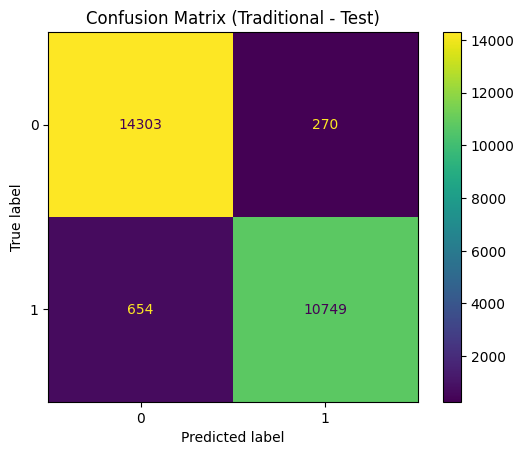

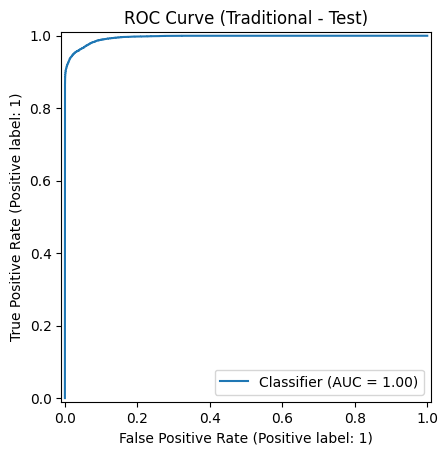

Saved: /mnt/d/wsl-data/Document/ML_252/notebooks/outputs/traditional_test_predictions_reload.csv


In [58]:
# 4.1) Reload + run test (Traditional / Section 2)
ensure_xy_loaded()

OUT_DIR = globals().get("OUT_DIR", Path("./runs/default"))
ARTIFACTS_DIR = globals().get("ARTIFACTS_DIR", OUT_DIR / "artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

trad_path = ARTIFACTS_DIR / "best_pipeline.joblib"
if not trad_path.exists():
    raise FileNotFoundError(
        f"Không thấy {trad_path}. Bạn cần chạy Section 2 (train + save) ít nhất 1 lần để tạo file này."
    )

trad_pipe = joblib.load(trad_path)
print("Loaded traditional model:", trad_path)

if y_test is None:
    trad_pred = trad_pipe.predict(X_test)
    display(pd.Series(trad_pred).value_counts().rename("pred_counts"))
else:
    trad_pred = evaluate_on_test(trad_pipe, X_test, y_test, title="Traditional")

pred_df = pd.DataFrame({"y_pred": trad_pred})
pred_out = OUT_DIR / "traditional_test_predictions_reload.csv"
pred_df.to_csv(pred_out, index=False)
print("Saved:", pred_out)
